# AirFly Insights — Week 4: Delay Analysis, Temporal Intelligence & Data Transformations

**Dataset:** NYC Flights 2013 — preprocessed (`flights_processed.csv`)

**Goals for Week 4:**
- Analyze delay causes using seasonal/temporal proxies (weather, carrier, congestion)
- Apply rolling averages and temporal trend decomposition
- Perform data transformations (log, normalization) on delay distributions
- Create advanced heatmaps, violin plots, and cumulative trend charts

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 12
sns.set_palette('tab10')

# Constants
SEASON_MAP = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
}
SEASON_ORDER = ['Winter', 'Spring', 'Summer', 'Fall']
MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
DAY_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

FIGURES_DIR = '../outputs/figures'

print('Setup complete.')

Setup complete.


## 2. Load Preprocessed Data

In [2]:
df = pd.read_csv('../data/processed/flights_processed.csv', low_memory=False)
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Add season column
df['season'] = df['month'].map(SEASON_MAP)

# Working subset: non-cancelled flights
df_completed = df[df['is_cancelled'] == 0].copy()

print(f'Total rows: {len(df):,}')
print(f'Completed flights: {len(df_completed):,}')
print(f'Cancelled flights: {(df["is_cancelled"] == 1).sum():,}')
print(f'Columns: {df.shape[1]}')

Total rows: 336,776
Completed flights: 328,521
Cancelled flights: 8,255
Columns: 35


---
## 3. Delay Cause Proxy Analysis

The nycflights13 dataset does not include explicit delay cause columns (weather, carrier, NAS). We infer delay causes using **temporal and carrier-based proxies**:

| Proxy | Rationale |
|-------|-----------|
| **Weather** | Winter months (Dec–Feb) and summer storm season (Jun–Aug) show elevated delays |
| **Carrier-specific** | Excess delay per carrier above the fleet-wide average |
| **Congestion (NAS)** | Evening flights accumulate cascading delays from earlier disruptions |

### 3.1 Seasonal Delay Analysis (Weather Proxy)

In [3]:
# Delay metrics by season
season_stats = df_completed.groupby('season').agg(
    total_flights=('dep_delay', 'count'),
    avg_dep_delay=('dep_delay', 'mean'),
    avg_arr_delay=('arr_delay', 'mean'),
    median_dep_delay=('dep_delay', 'median'),
    delay_rate=('is_delayed', 'mean'),
    cancel_rate=('is_cancelled', 'mean')
).reindex(SEASON_ORDER).round(2)

# Overall cancellation rate by season (including cancelled flights)
season_cancel = df.groupby(df['month'].map(SEASON_MAP))['is_cancelled'].mean().reindex(SEASON_ORDER)
season_stats['cancel_rate'] = (season_cancel * 100).round(2).values
season_stats['delay_rate'] = (season_stats['delay_rate'] * 100).round(2)

print('=== Delay Metrics by Season ===')
season_stats

=== Delay Metrics by Season ===


,total_flights,avg_dep_delay,avg_arr_delay,median_dep_delay,delay_rate,cancel_rate
season,,,,,,
Winter,77283,12.57,9.04,-1.0,22.0,3.50
Spring,83868,13.38,6.81,-2.0,23.0,2.43
Summer,84560,18.33,12.99,0.0,27.0,2.80
Fall,82810,6.14,-1.22,-3.0,14.0,1.10


### Chart 11: Seasonal Delay Comparison

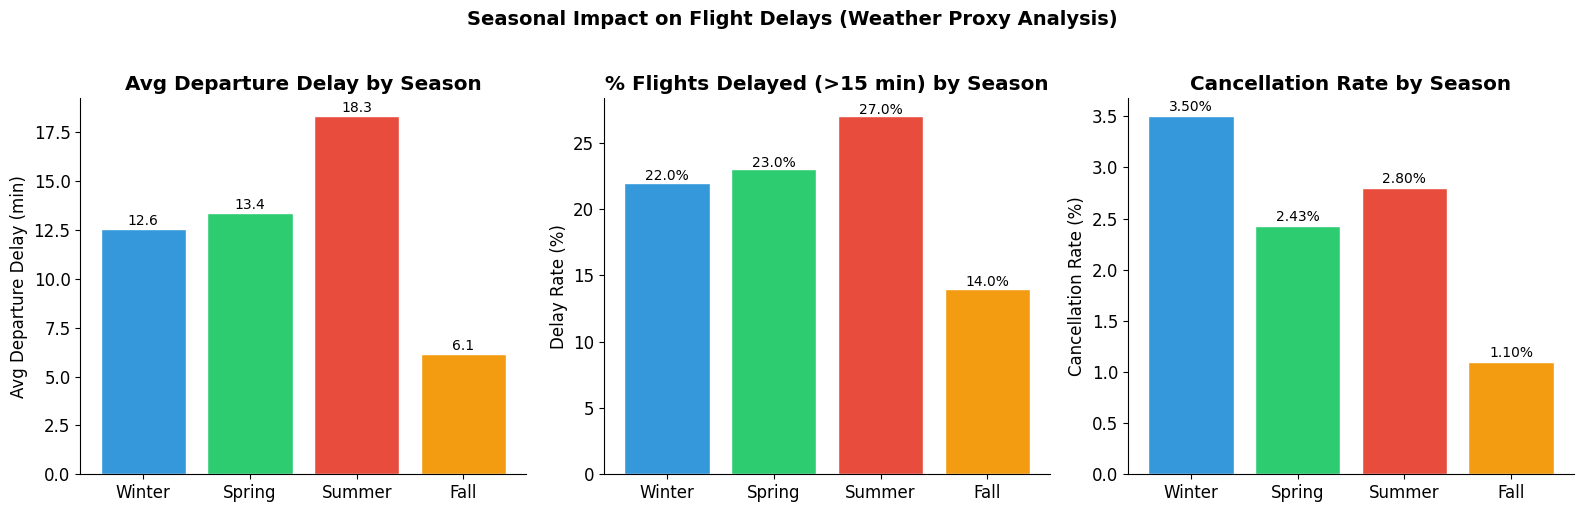

Chart 11 saved.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
season_colors = {'Winter': '#3498db', 'Spring': '#2ecc71', 'Summer': '#e74c3c', 'Fall': '#f39c12'}
colors = [season_colors[s] for s in SEASON_ORDER]

# Average departure delay
bars1 = axes[0].bar(SEASON_ORDER, season_stats['avg_dep_delay'], color=colors, edgecolor='white')
axes[0].set_ylabel('Avg Departure Delay (min)')
axes[0].set_title('Avg Departure Delay by Season', fontweight='bold')
for bar, val in zip(bars1, season_stats['avg_dep_delay']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}', ha='center', fontsize=10)

# Delay rate
bars2 = axes[1].bar(SEASON_ORDER, season_stats['delay_rate'], color=colors, edgecolor='white')
axes[1].set_ylabel('Delay Rate (%)')
axes[1].set_title('% Flights Delayed (>15 min) by Season', fontweight='bold')
for bar, val in zip(bars2, season_stats['delay_rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', fontsize=10)

# Cancellation rate
bars3 = axes[2].bar(SEASON_ORDER, season_stats['cancel_rate'], color=colors, edgecolor='white')
axes[2].set_ylabel('Cancellation Rate (%)')
axes[2].set_title('Cancellation Rate by Season', fontweight='bold')
for bar, val in zip(bars3, season_stats['cancel_rate']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}%', ha='center', fontsize=10)

plt.suptitle('Seasonal Impact on Flight Delays (Weather Proxy Analysis)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/chart11_seasonal_delay_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 11 saved.')

### 3.2 Delay Severity Distribution by Season

### Chart 12: Delay Severity by Season (Stacked Bar)

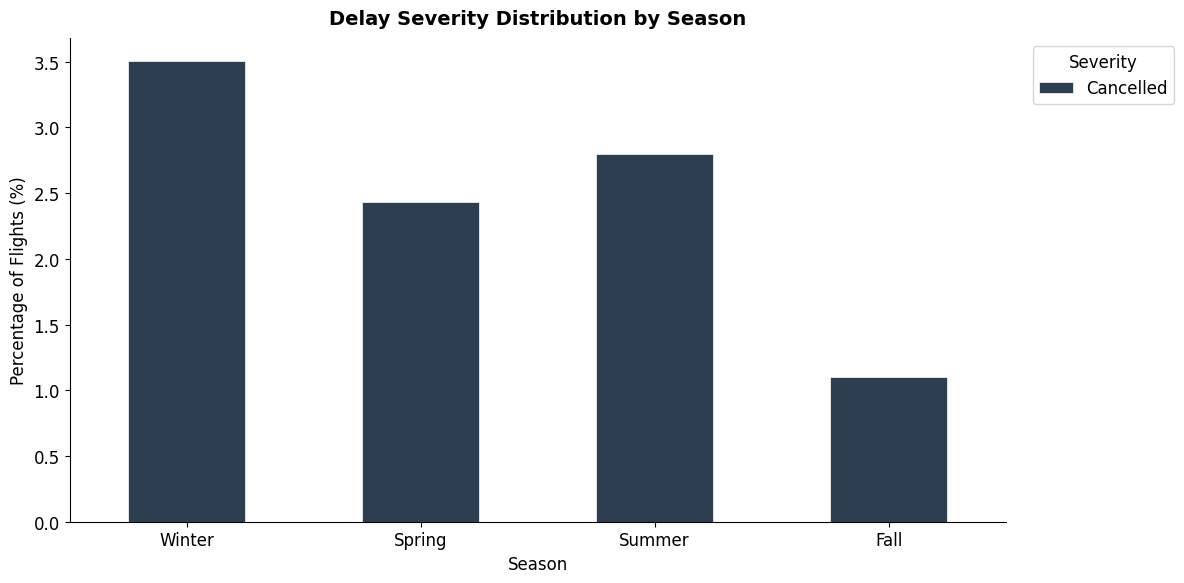

Chart 12 saved.


In [5]:
# Cross-tab of season vs delay severity
severity_order = ['On Time', 'Minor Delay', 'Moderate Delay', 'Severe Delay', 'Extreme Delay', 'Cancelled']
severity_season = pd.crosstab(df['season'], df['delay_severity'], normalize='index') * 100

# Reorder columns and rows
available_cols = [c for c in severity_order if c in severity_season.columns]
severity_season = severity_season.reindex(index=SEASON_ORDER, columns=available_cols)

fig, ax = plt.subplots(figsize=(12, 6))
severity_colors = {
    'On Time': '#2ecc71', 'Minor Delay': '#f1c40f', 'Moderate Delay': '#e67e22',
    'Severe Delay': '#e74c3c', 'Extreme Delay': '#8e44ad', 'Cancelled': '#2c3e50'
}
colors_list = [severity_colors.get(c, '#95a5a6') for c in available_cols]
severity_season.plot(kind='bar', stacked=True, ax=ax, color=colors_list, edgecolor='white', linewidth=0.5)

ax.set_ylabel('Percentage of Flights (%)')
ax.set_xlabel('Season')
ax.set_title('Delay Severity Distribution by Season', fontsize=14, fontweight='bold', pad=10)
ax.legend(title='Severity', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels(SEASON_ORDER, rotation=0)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/chart12_severity_by_season.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 12 saved.')

### 3.3 Carrier-Specific Delay Analysis

In [6]:
# Carrier delay vs fleet-wide average
overall_avg = df_completed['dep_delay'].mean()
carrier_stats = df_completed.groupby('name').agg(
    avg_delay=('dep_delay', 'mean'),
    flight_count=('dep_delay', 'count'),
    delay_rate=('is_delayed', 'mean')
).sort_values('avg_delay', ascending=False)

carrier_stats['excess_delay'] = carrier_stats['avg_delay'] - overall_avg
carrier_stats['delay_rate'] = (carrier_stats['delay_rate'] * 100).round(2)

print(f'Fleet-wide average departure delay: {overall_avg:.2f} min')
print(f'\n=== Carrier Excess Delay (above/below fleet average) ===')
carrier_stats[['avg_delay', 'excess_delay', 'delay_rate', 'flight_count']].round(2)

Fleet-wide average departure delay: 12.64 min

=== Carrier Excess Delay (above/below fleet average) ===


,avg_delay,excess_delay,delay_rate,flight_count
name,,,,
Frontier Airlines Inc.,20.22,7.58,28.15,682
ExpressJet Airlines Inc.,19.96,7.32,30.46,51356
Mesa Airlines Inc.,19.00,6.36,28.62,545
AirTran Airways Corporation,18.73,6.09,26.67,3187
Southwest Airlines Co.,17.71,5.07,26.90,12083
Endeavor Air Inc.,16.73,4.09,25.67,17416
JetBlue Airways,13.02,0.38,22.80,54169
Virgin America,12.87,0.23,17.40,5131
SkyWest Airlines Inc.,12.59,-0.05,20.69,29


### Chart 13: Carrier Excess Delay (Diverging Bar)

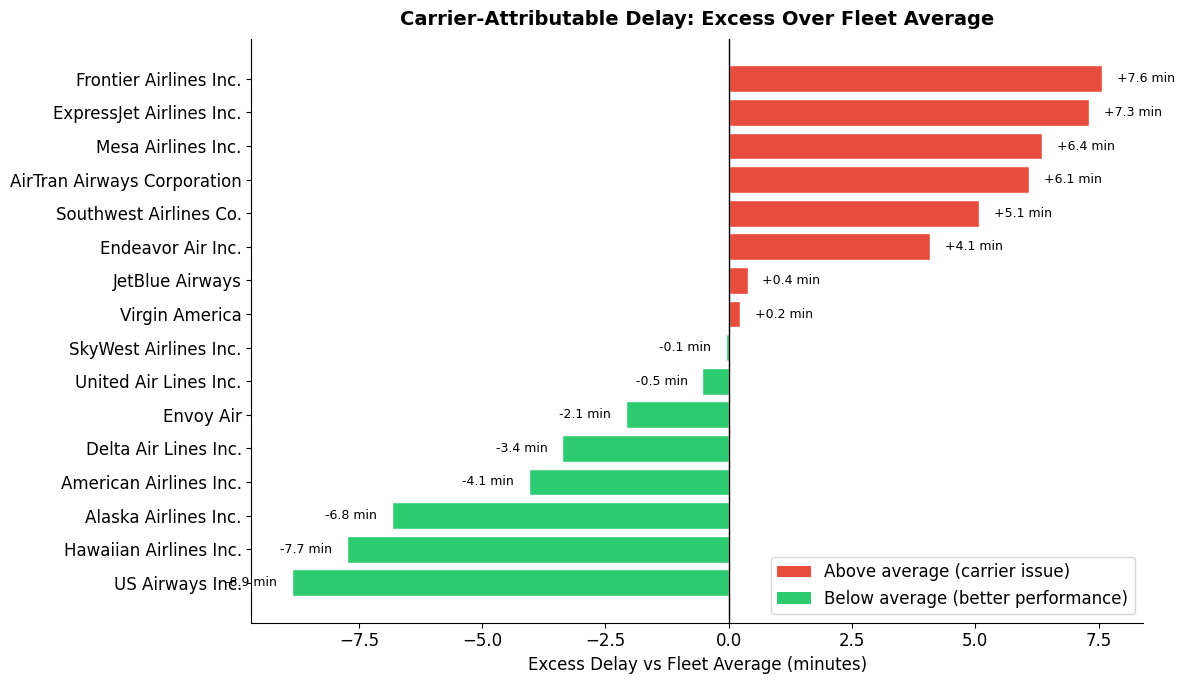

Chart 13 saved.


In [7]:
carrier_excess = carrier_stats['excess_delay'].sort_values()

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in carrier_excess.values]
bars = ax.barh(carrier_excess.index, carrier_excess.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Excess Delay vs Fleet Average (minutes)')
ax.set_title('Carrier-Attributable Delay: Excess Over Fleet Average',
             fontsize=14, fontweight='bold', pad=10)

for bar, val in zip(bars, carrier_excess.values):
    offset = 0.3 if val >= 0 else -0.3
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:+.1f} min', va='center', ha=ha, fontsize=9)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Above average (carrier issue)'),
                   Patch(facecolor='#2ecc71', label='Below average (better performance)')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/chart13_carrier_excess_delay.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 13 saved.')

### 3.4 Time-of-Day Congestion Analysis (NAS Proxy)

### Chart 14: Hourly Delay Accumulation (Cascading Delay Pattern)

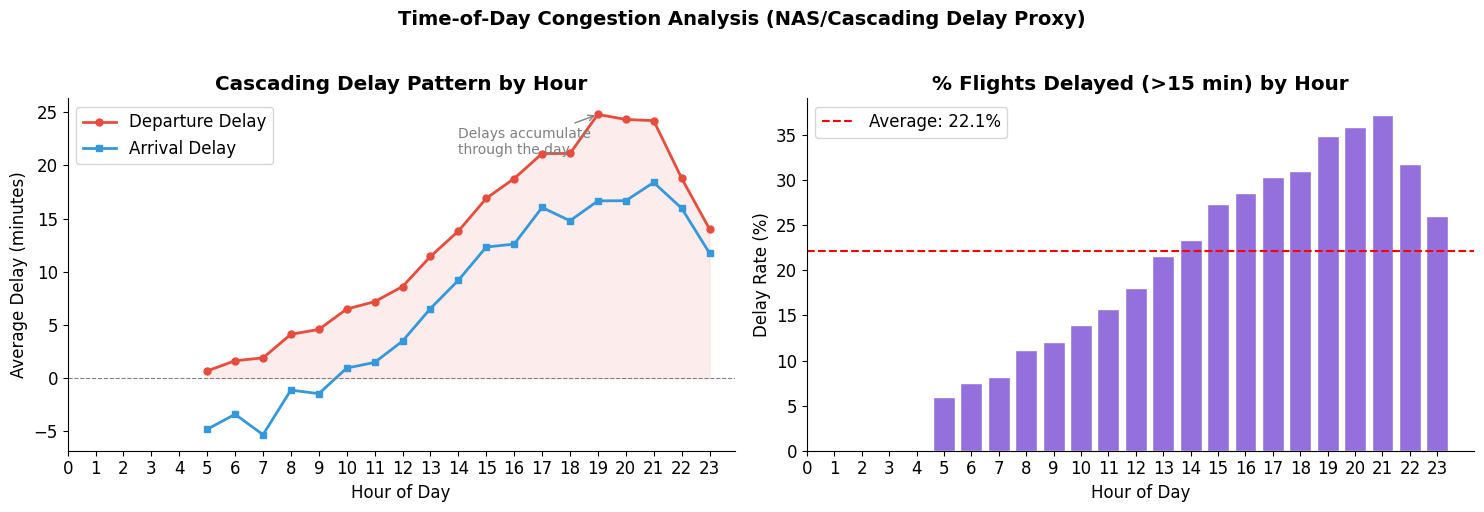

Chart 14 saved.


In [8]:
hourly_delay = df_completed.groupby('hour').agg(
    avg_dep_delay=('dep_delay', 'mean'),
    avg_arr_delay=('arr_delay', 'mean'),
    delay_rate=('is_delayed', 'mean')
)
hourly_delay['delay_rate'] = hourly_delay['delay_rate'] * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Left: Average delay by hour
ax1.plot(hourly_delay.index, hourly_delay['avg_dep_delay'], marker='o', linewidth=2,
         color='#e74c3c', label='Departure Delay', markersize=5)
ax1.plot(hourly_delay.index, hourly_delay['avg_arr_delay'], marker='s', linewidth=2,
         color='#3498db', label='Arrival Delay', markersize=5)
ax1.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax1.fill_between(hourly_delay.index, hourly_delay['avg_dep_delay'], alpha=0.1, color='#e74c3c')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Average Delay (minutes)')
ax1.set_title('Cascading Delay Pattern by Hour', fontweight='bold')
ax1.set_xticks(range(0, 24))
ax1.legend()
ax1.annotate('Delays accumulate\nthrough the day',
             xy=(19, hourly_delay.loc[19, 'avg_dep_delay']),
             xytext=(14, hourly_delay['avg_dep_delay'].max() * 0.85),
             arrowprops=dict(arrowstyle='->', color='gray'),
             fontsize=10, color='gray')

# Right: Delay rate by hour
ax2.bar(hourly_delay.index, hourly_delay['delay_rate'], color='mediumpurple', edgecolor='white')
ax2.axhline(hourly_delay['delay_rate'].mean(), color='red', linestyle='--',
            label=f'Average: {hourly_delay["delay_rate"].mean():.1f}%')
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Delay Rate (%)')
ax2.set_title('% Flights Delayed (>15 min) by Hour', fontweight='bold')
ax2.set_xticks(range(0, 24))
ax2.legend()

plt.suptitle('Time-of-Day Congestion Analysis (NAS/Cascading Delay Proxy)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/chart14_hourly_delay_cascade.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 14 saved.')

### Chart 15: Delay Heatmap — Hour × Day of Week

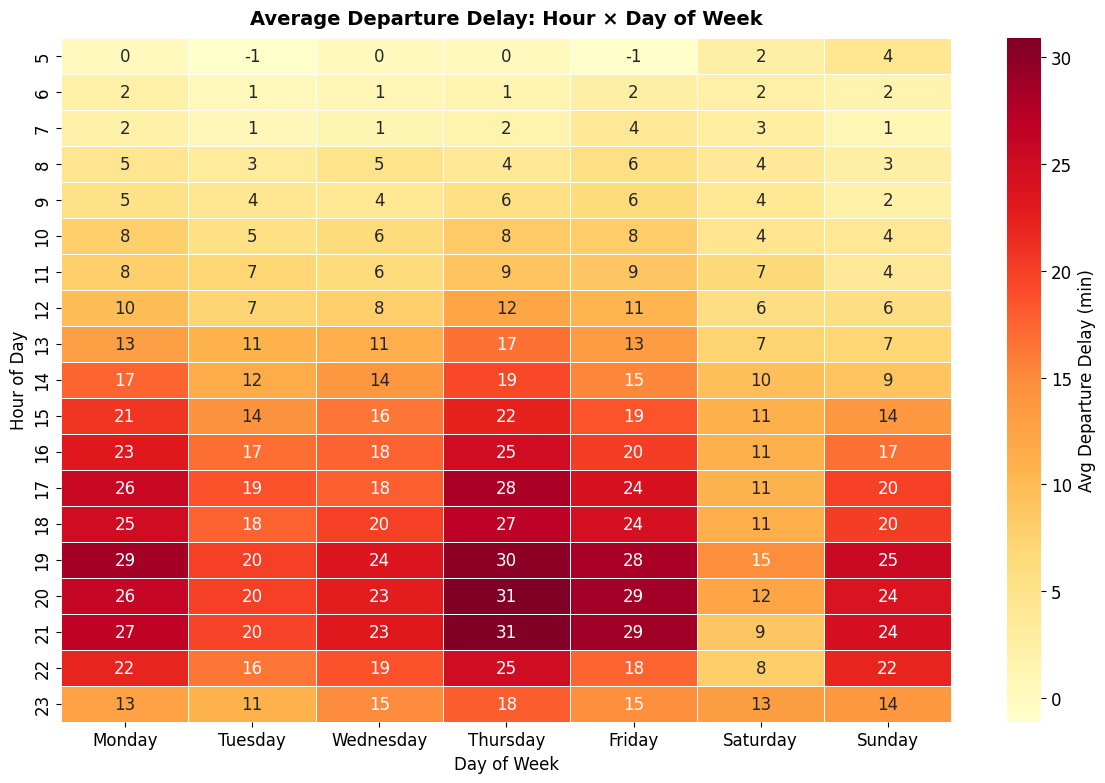

Chart 15 saved.


In [9]:
# Pivot: avg delay by hour and day of week
heatmap_data = df_completed.pivot_table(
    values='dep_delay', index='hour', columns='day_name', aggfunc='mean'
).reindex(columns=DAY_ORDER)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='.0f', linewidths=0.5,
            ax=ax, cbar_kws={'label': 'Avg Departure Delay (min)'})
ax.set_xlabel('Day of Week')
ax.set_ylabel('Hour of Day')
ax.set_title('Average Departure Delay: Hour × Day of Week',
             fontsize=14, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/chart15_delay_heatmap_hour_day.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 15 saved.')

### Chart 16: Delay Heatmap — Month × Carrier

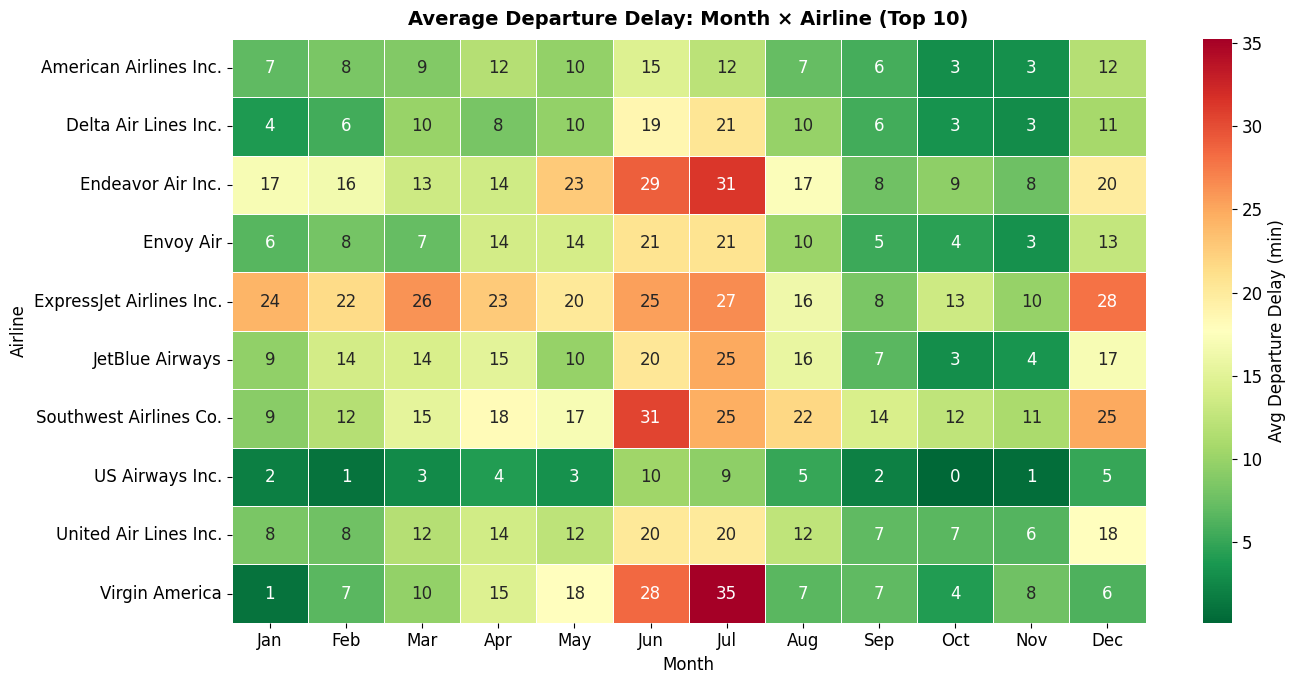

Chart 16 saved.


In [10]:
# Top 10 carriers by volume for readability
top10_carriers = df_completed['name'].value_counts().head(10).index.tolist()
df_top10 = df_completed[df_completed['name'].isin(top10_carriers)]

heatmap_carrier = df_top10.pivot_table(
    values='dep_delay', index='name', columns='month', aggfunc='mean'
)
heatmap_carrier.columns = MONTH_NAMES

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(heatmap_carrier, cmap='RdYlGn_r', annot=True, fmt='.0f', linewidths=0.5,
            ax=ax, cbar_kws={'label': 'Avg Departure Delay (min)'})
ax.set_xlabel('Month')
ax.set_ylabel('Airline')
ax.set_title('Average Departure Delay: Month × Airline (Top 10)',
             fontsize=14, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/chart16_delay_heatmap_month_carrier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 16 saved.')

---
## 4. Rolling Averages & Temporal Intelligence

In [11]:
# Aggregate daily metrics
daily = df_completed.groupby('date').agg(
    avg_dep_delay=('dep_delay', 'mean'),
    avg_arr_delay=('arr_delay', 'mean'),
    total_flights=('dep_delay', 'count'),
    delay_rate=('is_delayed', 'mean'),
    cancel_count=('is_cancelled', 'sum')
).sort_index()

daily.index = pd.to_datetime(daily.index)

# Rolling averages
daily['delay_7d'] = daily['avg_dep_delay'].rolling(7, min_periods=1).mean()
daily['delay_30d'] = daily['avg_dep_delay'].rolling(30, min_periods=1).mean()
daily['delay_rate_7d'] = daily['delay_rate'].rolling(7, min_periods=1).mean() * 100

print(f'Daily aggregation: {len(daily)} days')
print(f'Date range: {daily.index.min().date()} to {daily.index.max().date()}')
daily.head()

Daily aggregation: 365 days
Date range: 2013-01-01 to 2013-12-31


,avg_dep_delay,avg_arr_delay,total_flights,delay_rate,cancel_count,delay_7d,delay_30d,delay_rate_7d
date,,,,,,,,
2013-01-01,11.548926,12.651023,838,0.188544,0,11.548926,11.548926,18.854415
2013-01-02,13.858824,12.692888,935,0.223529,0,12.703875,12.703875,20.603678
2013-01-03,10.987832,5.733333,904,0.213496,0,12.131860,12.131860,20.852305
2013-01-04,8.951595,-1.932819,909,0.201320,0,11.336794,11.336794,20.672232
2013-01-05,5.732218,-1.525802,717,0.133891,0,10.215879,10.215879,19.215610


### Chart 17: Daily Delay with Rolling Averages

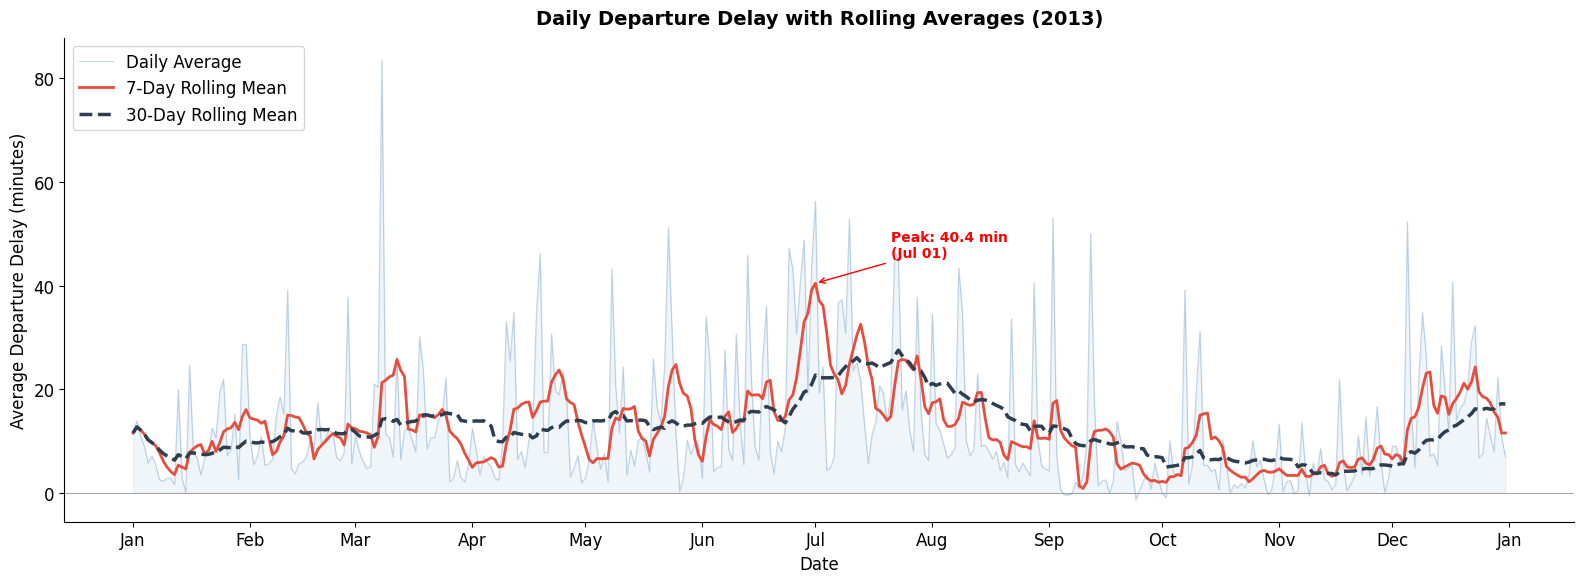

Chart 17 saved.


In [12]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(daily.index, daily['avg_dep_delay'], alpha=0.3, color='steelblue',
        linewidth=0.8, label='Daily Average')
ax.plot(daily.index, daily['delay_7d'], color='#e74c3c', linewidth=2,
        label='7-Day Rolling Mean')
ax.plot(daily.index, daily['delay_30d'], color='#2c3e50', linewidth=2.5,
        linestyle='--', label='30-Day Rolling Mean')

ax.axhline(0, color='gray', linewidth=0.5, linestyle='-')
ax.fill_between(daily.index, daily['avg_dep_delay'], alpha=0.08, color='steelblue')

# Annotate peak delay periods
peak_idx = daily['delay_7d'].idxmax()
peak_val = daily.loc[peak_idx, 'delay_7d']
ax.annotate(f'Peak: {peak_val:.1f} min\n({peak_idx.strftime("%b %d")})',
            xy=(peak_idx, peak_val),
            xytext=(peak_idx + pd.Timedelta(days=20), peak_val + 5),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red', fontweight='bold')

ax.set_xlabel('Date')
ax.set_ylabel('Average Departure Delay (minutes)')
ax.set_title('Daily Departure Delay with Rolling Averages (2013)',
             fontsize=14, fontweight='bold', pad=10)
ax.legend(loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/chart17_daily_delay_rolling_avg.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 17 saved.')

### Chart 18: Rolling Delay Rate Over Time

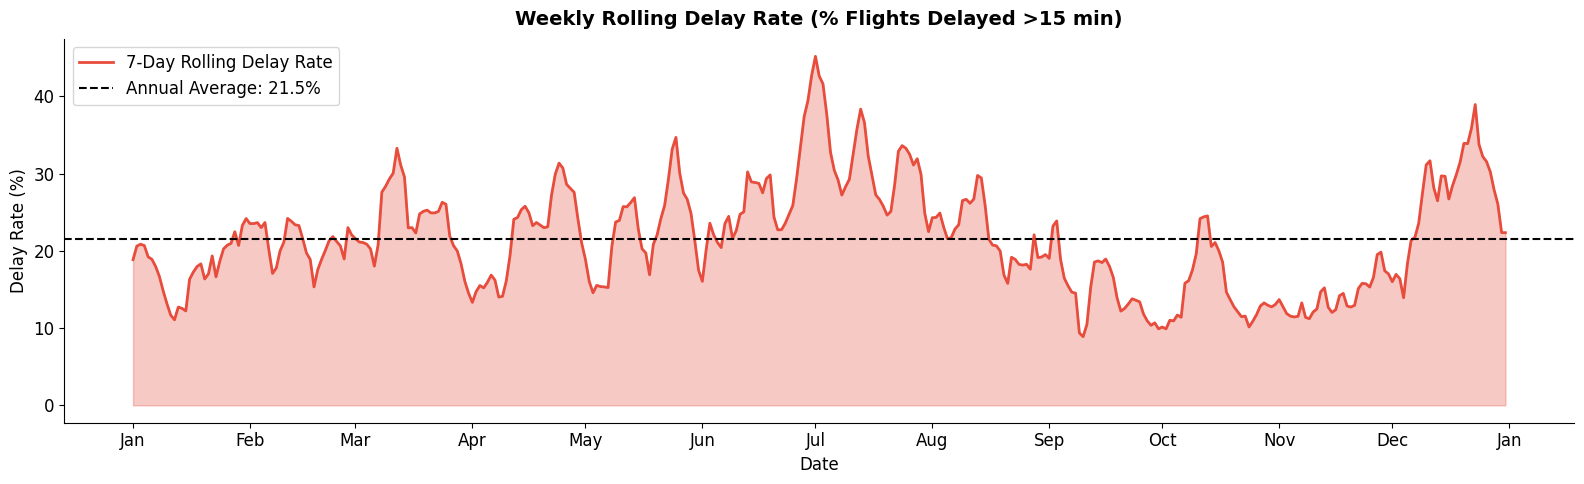

Chart 18 saved.


In [13]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.fill_between(daily.index, daily['delay_rate_7d'], alpha=0.3, color='#e74c3c')
ax.plot(daily.index, daily['delay_rate_7d'], color='#e74c3c', linewidth=2,
        label='7-Day Rolling Delay Rate')

overall_rate = (df_completed['is_delayed'].mean() * 100)
ax.axhline(overall_rate, color='black', linestyle='--', linewidth=1.5,
           label=f'Annual Average: {overall_rate:.1f}%')

ax.set_xlabel('Date')
ax.set_ylabel('Delay Rate (%)')
ax.set_title('Weekly Rolling Delay Rate (% Flights Delayed >15 min)',
             fontsize=14, fontweight='bold', pad=10)
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/chart18_rolling_delay_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 18 saved.')

### 4.1 Temporal Decomposition (Trend + Seasonality + Residual)

In [14]:
# Manual decomposition using rolling averages
# Trend = 30-day rolling mean
# Seasonal = 7-day rolling mean - Trend
# Residual = Actual - Trend - Seasonal

decomp = daily[['avg_dep_delay']].copy()
decomp['trend'] = decomp['avg_dep_delay'].rolling(30, center=True, min_periods=1).mean()
decomp['detrended'] = decomp['avg_dep_delay'] - decomp['trend']
decomp['seasonal'] = decomp['detrended'].rolling(7, center=True, min_periods=1).mean()
decomp['residual'] = decomp['avg_dep_delay'] - decomp['trend'] - decomp['seasonal']

### Chart 19: Temporal Decomposition of Daily Delays

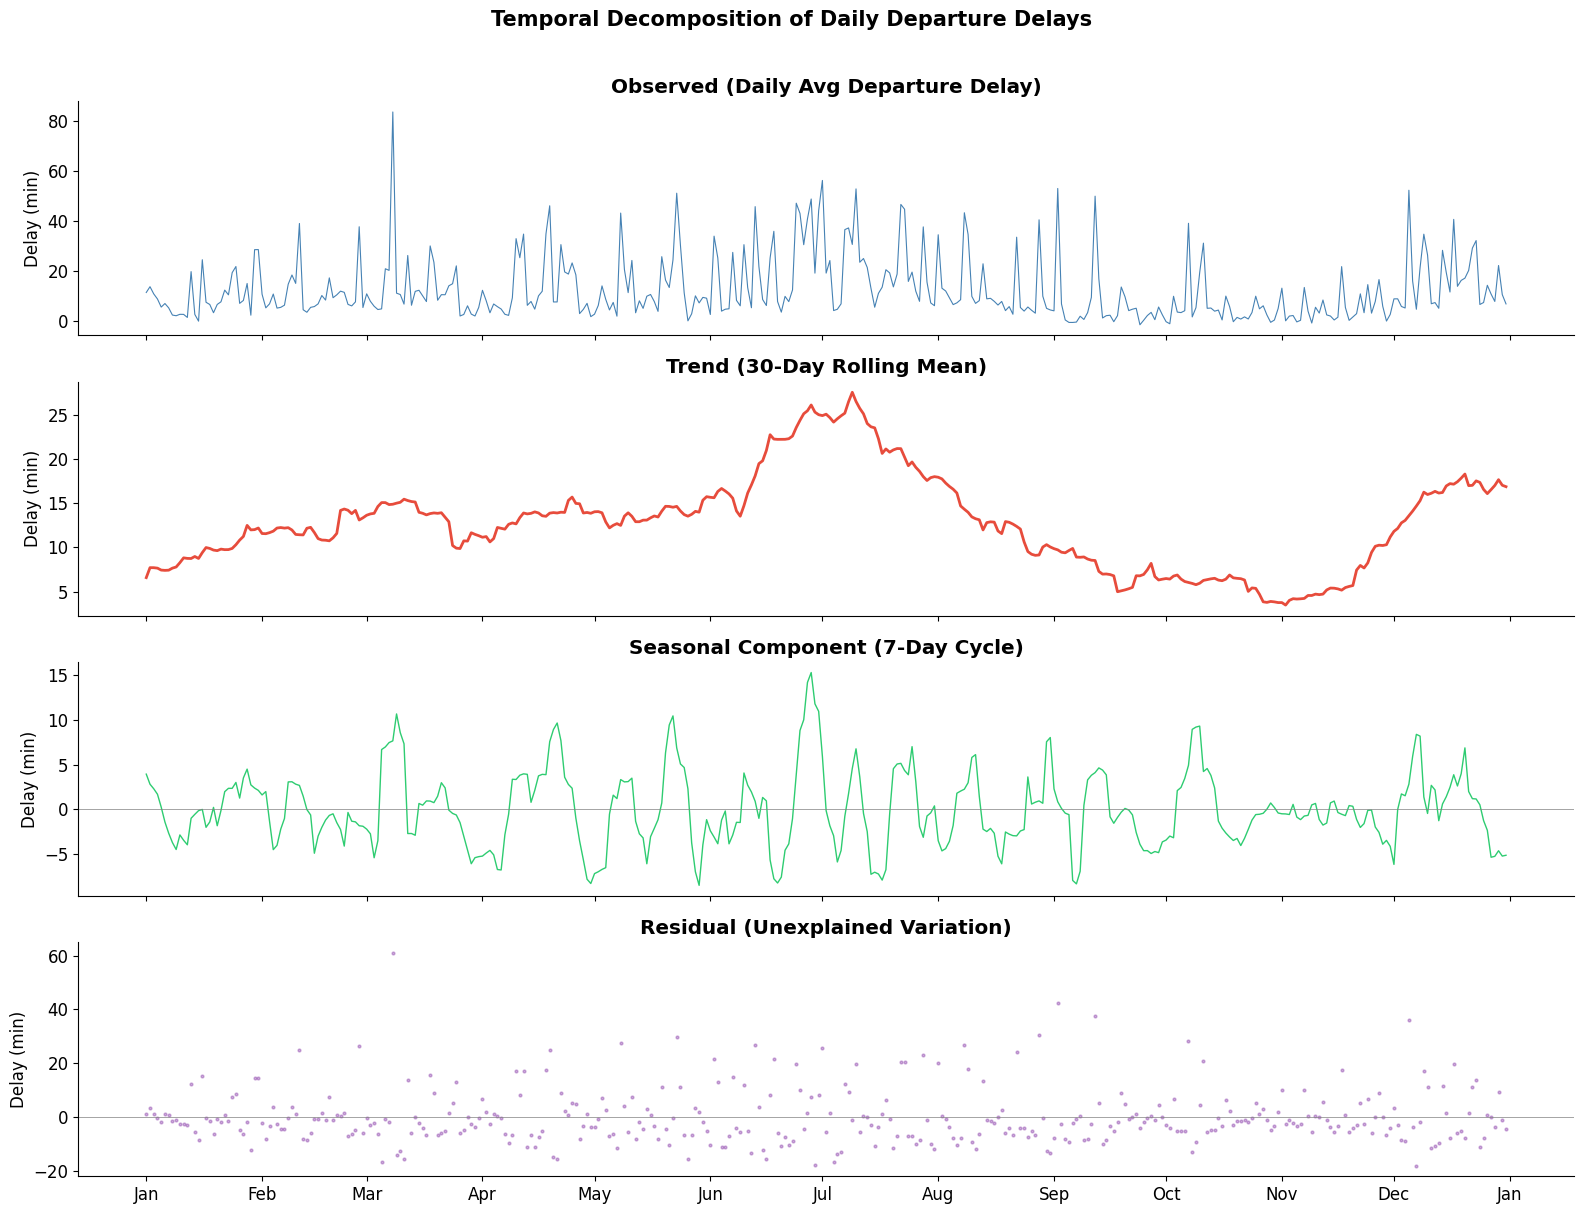

Chart 19 saved.


In [15]:
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

# Original
axes[0].plot(decomp.index, decomp['avg_dep_delay'], color='steelblue', linewidth=0.8)
axes[0].set_ylabel('Delay (min)')
axes[0].set_title('Observed (Daily Avg Departure Delay)', fontweight='bold')

# Trend
axes[1].plot(decomp.index, decomp['trend'], color='#e74c3c', linewidth=2)
axes[1].set_ylabel('Delay (min)')
axes[1].set_title('Trend (30-Day Rolling Mean)', fontweight='bold')

# Seasonal
axes[2].plot(decomp.index, decomp['seasonal'], color='#2ecc71', linewidth=1)
axes[2].axhline(0, color='gray', linewidth=0.5)
axes[2].set_ylabel('Delay (min)')
axes[2].set_title('Seasonal Component (7-Day Cycle)', fontweight='bold')

# Residual
axes[3].scatter(decomp.index, decomp['residual'], s=4, alpha=0.5, color='#9b59b6')
axes[3].axhline(0, color='gray', linewidth=0.5)
axes[3].set_ylabel('Delay (min)')
axes[3].set_title('Residual (Unexplained Variation)', fontweight='bold')
axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[3].xaxis.set_major_locator(mdates.MonthLocator())

plt.suptitle('Temporal Decomposition of Daily Departure Delays',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/chart19_temporal_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 19 saved.')

---
## 5. Data Transformations

### 5.1 Log Transform on Departure Delay

### Chart 20: Raw vs Log-Transformed Delay Distribution

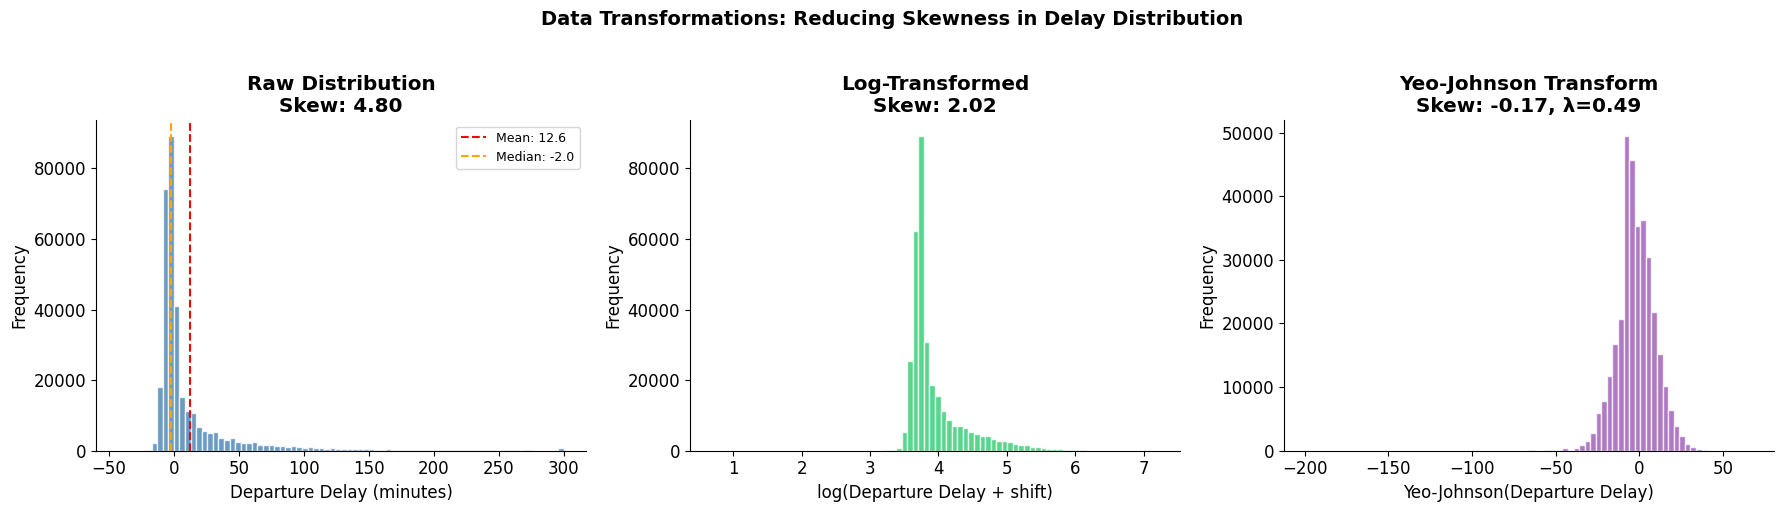

Chart 20 saved.


In [16]:
delays_raw = df_completed['dep_delay'].dropna()

# Shift to make all positive before log transform
shift = abs(delays_raw.min()) + 1
delays_shifted = delays_raw + shift
delays_log = np.log1p(delays_shifted)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Raw distribution
axes[0].hist(delays_raw.clip(-60, 300), bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(delays_raw.mean(), color='red', linestyle='--', label=f'Mean: {delays_raw.mean():.1f}')
axes[0].axvline(delays_raw.median(), color='orange', linestyle='--', label=f'Median: {delays_raw.median():.1f}')
axes[0].set_title(f'Raw Distribution\nSkew: {delays_raw.skew():.2f}', fontweight='bold')
axes[0].set_xlabel('Departure Delay (minutes)')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=9)

# Log-transformed
axes[1].hist(delays_log, bins=80, color='#2ecc71', edgecolor='white', alpha=0.8)
axes[1].set_title(f'Log-Transformed\nSkew: {delays_log.skew():.2f}', fontweight='bold')
axes[1].set_xlabel('log(Departure Delay + shift)')
axes[1].set_ylabel('Frequency')

# Yeo-Johnson transform (handles negatives natively)
delays_yj, lam = stats.yeojohnson(delays_raw)
axes[2].hist(delays_yj, bins=80, color='#9b59b6', edgecolor='white', alpha=0.8)
axes[2].set_title(f'Yeo-Johnson Transform\nSkew: {pd.Series(delays_yj).skew():.2f}, λ={lam:.2f}',
                  fontweight='bold')
axes[2].set_xlabel('Yeo-Johnson(Departure Delay)')
axes[2].set_ylabel('Frequency')

plt.suptitle('Data Transformations: Reducing Skewness in Delay Distribution',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/chart20_delay_transformations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 20 saved.')

### 5.2 Min-Max Normalization for Cross-Carrier Comparison

### Chart 21: Normalized Delay by Carrier (Min-Max Scaled)

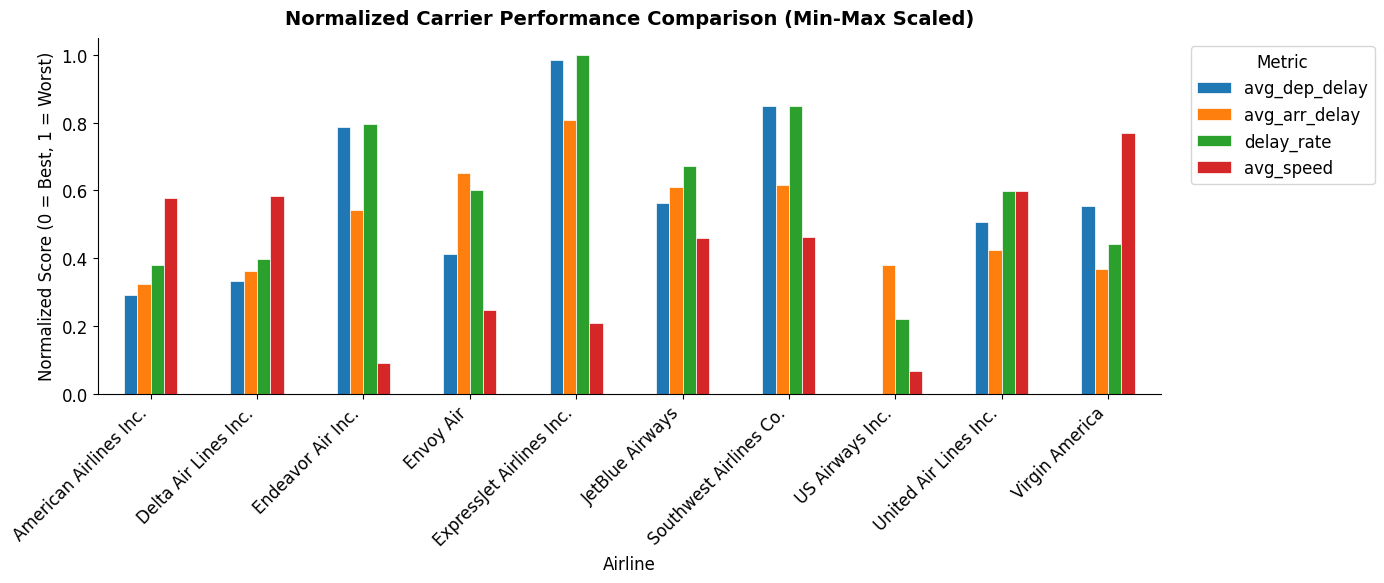

Chart 21 saved.


In [17]:
# Carrier-level metrics
carrier_metrics = df_completed.groupby('name').agg(
    avg_dep_delay=('dep_delay', 'mean'),
    avg_arr_delay=('arr_delay', 'mean'),
    delay_rate=('is_delayed', 'mean'),
    avg_speed=('speed_mph', 'mean')
).dropna()

# Min-Max normalize each column to [0, 1]
carrier_norm = carrier_metrics.copy()
for col in carrier_norm.columns:
    cmin, cmax = carrier_norm[col].min(), carrier_norm[col].max()
    carrier_norm[col] = (carrier_norm[col] - cmin) / (cmax - cmin) if cmax > cmin else 0

# Plot top 10 carriers
top10_names = df_completed['name'].value_counts().head(10).index
carrier_norm_top = carrier_norm.loc[carrier_norm.index.isin(top10_names)].sort_index()

fig, ax = plt.subplots(figsize=(14, 6))
carrier_norm_top.plot(kind='bar', ax=ax, edgecolor='white', linewidth=0.5)
ax.set_ylabel('Normalized Score (0 = Best, 1 = Worst)')
ax.set_xlabel('Airline')
ax.set_title('Normalized Carrier Performance Comparison (Min-Max Scaled)',
             fontsize=14, fontweight='bold', pad=10)
ax.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/chart21_normalized_carrier_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 21 saved.')

---
## 6. Advanced Delay Visualizations

### Chart 22: Violin Plot — Delay by Origin Airport Across Seasons

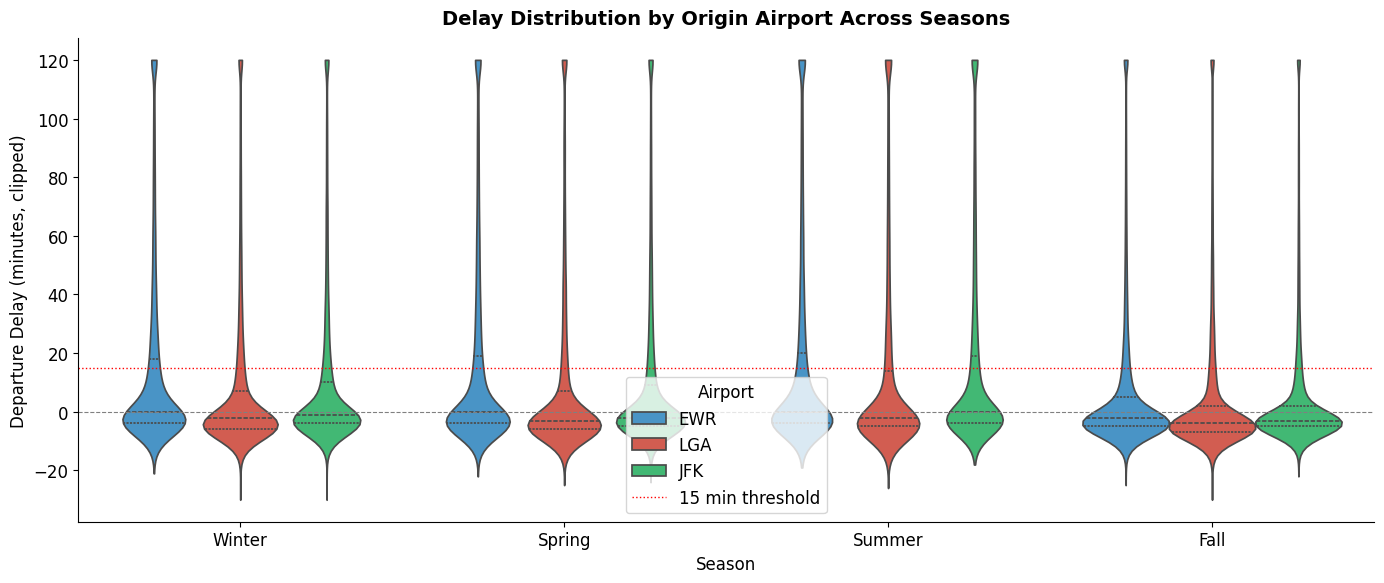

Chart 22 saved.


In [18]:
df_violin = df_completed[['origin', 'dep_delay', 'season']].dropna()
df_violin['dep_delay_clipped'] = df_violin['dep_delay'].clip(-30, 120)

fig, ax = plt.subplots(figsize=(14, 6))
sns.violinplot(data=df_violin, x='season', y='dep_delay_clipped', hue='origin',
               order=SEASON_ORDER, palette={'EWR': '#3498db', 'JFK': '#2ecc71', 'LGA': '#e74c3c'},
               split=False, inner='quartile', ax=ax, cut=0)

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.axhline(15, color='red', linestyle=':', linewidth=1, label='15 min threshold')
ax.set_xlabel('Season')
ax.set_ylabel('Departure Delay (minutes, clipped)')
ax.set_title('Delay Distribution by Origin Airport Across Seasons',
             fontsize=14, fontweight='bold', pad=10)
ax.legend(title='Airport')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/chart22_violin_origin_season.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 22 saved.')

### Chart 23: Cumulative Delay Trend Over the Year

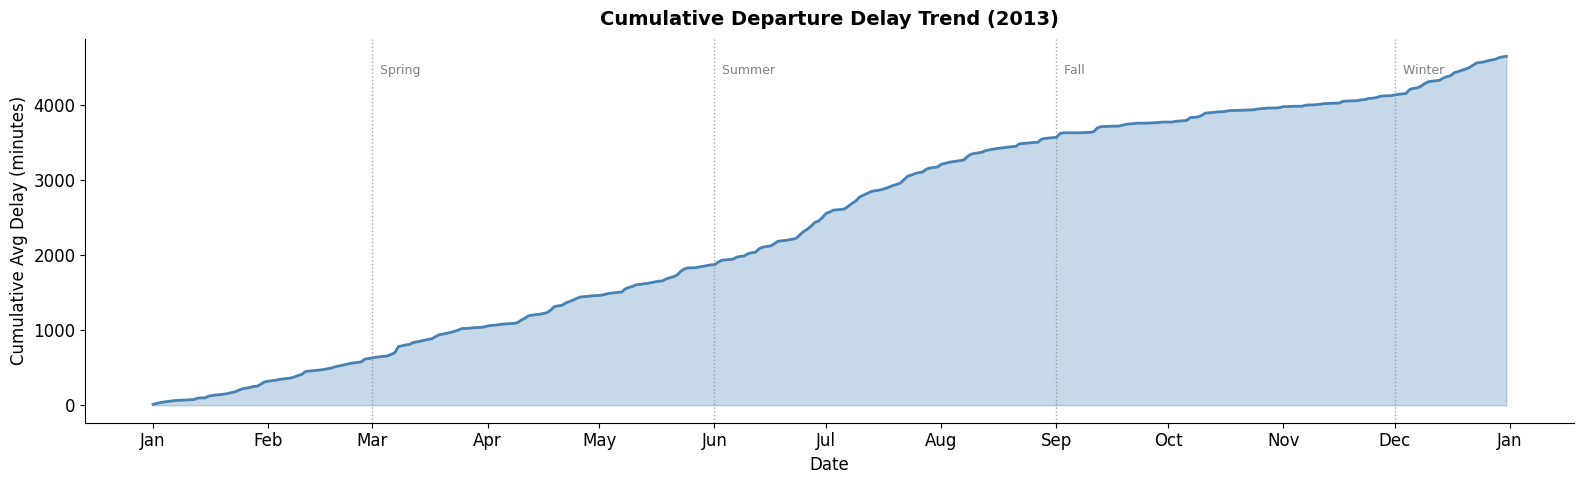

Chart 23 saved.


In [19]:
daily['cumulative_delay'] = daily['avg_dep_delay'].cumsum()

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(daily.index, daily['cumulative_delay'], alpha=0.3, color='steelblue')
ax.plot(daily.index, daily['cumulative_delay'], color='steelblue', linewidth=2)

# Mark season boundaries
season_starts = {
    'Spring': '2013-03-01', 'Summer': '2013-06-01',
    'Fall': '2013-09-01', 'Winter': '2013-12-01'
}
for label, date_str in season_starts.items():
    date = pd.Timestamp(date_str)
    if date in daily.index:
        ax.axvline(date, color='gray', linestyle=':', linewidth=1, alpha=0.7)
        ax.text(date, daily['cumulative_delay'].max() * 0.95, f'  {label}',
                fontsize=9, color='gray')

ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Avg Delay (minutes)')
ax.set_title('Cumulative Departure Delay Trend (2013)',
             fontsize=14, fontweight='bold', pad=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/chart23_cumulative_delay_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 23 saved.')

### Chart 24: Monthly Delay by Season — Grouped Bar (Dep vs Arr)

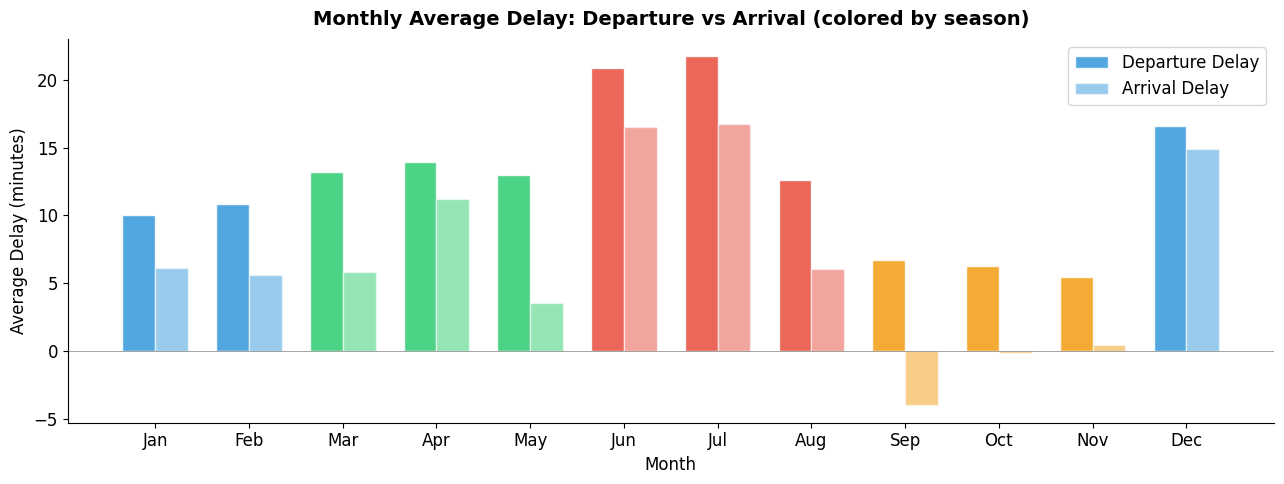

Chart 24 saved.


In [20]:
monthly_delays = df_completed.groupby('month').agg(
    avg_dep_delay=('dep_delay', 'mean'),
    avg_arr_delay=('arr_delay', 'mean')
).round(2)

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(12)
width = 0.35

# Color bars by season
season_bar_colors = [season_colors[SEASON_MAP[m+1]] for m in range(12)]

bars1 = ax.bar(x - width/2, monthly_delays['avg_dep_delay'], width, label='Departure Delay',
               color=[c for c in season_bar_colors], edgecolor='white', alpha=0.85)
bars2 = ax.bar(x + width/2, monthly_delays['avg_arr_delay'], width, label='Arrival Delay',
               color=[c for c in season_bar_colors], edgecolor='white', alpha=0.5)

ax.set_xlabel('Month')
ax.set_ylabel('Average Delay (minutes)')
ax.set_title('Monthly Average Delay: Departure vs Arrival (colored by season)',
             fontsize=14, fontweight='bold', pad=10)
ax.set_xticks(x)
ax.set_xticklabels(MONTH_NAMES)
ax.legend()
ax.axhline(0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/chart24_monthly_dep_vs_arr_delay.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 24 saved.')

### Chart 25: Rolling Cancellation Rate Over Time

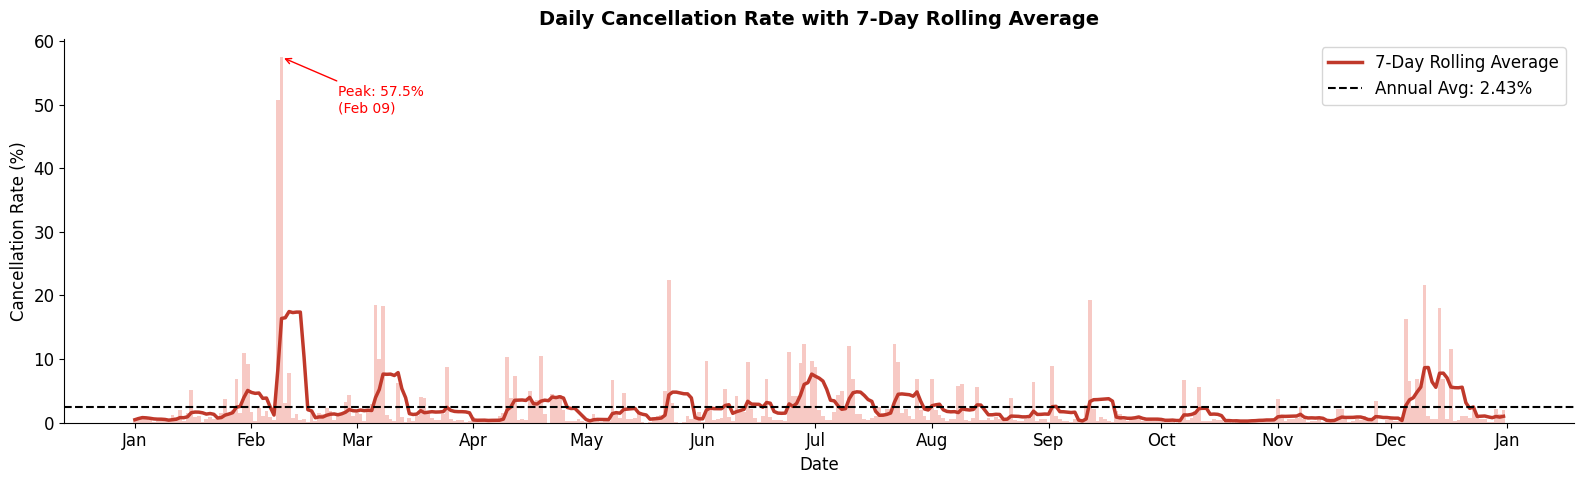

Chart 25 saved.


In [21]:
# Daily cancellation from ALL flights (including cancelled)
daily_all = df.groupby('date').agg(
    total=('is_cancelled', 'count'),
    cancelled=('is_cancelled', 'sum')
).sort_index()
daily_all.index = pd.to_datetime(daily_all.index)
daily_all['cancel_rate'] = daily_all['cancelled'] / daily_all['total'] * 100
daily_all['cancel_rate_7d'] = daily_all['cancel_rate'].rolling(7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(daily_all.index, daily_all['cancel_rate'], alpha=0.3, color='#e74c3c', width=1)
ax.plot(daily_all.index, daily_all['cancel_rate_7d'], color='#c0392b', linewidth=2.5,
        label='7-Day Rolling Average')
ax.axhline(daily_all['cancel_rate'].mean(), color='black', linestyle='--',
           label=f'Annual Avg: {daily_all["cancel_rate"].mean():.2f}%')

# Annotate spike
spike_idx = daily_all['cancel_rate'].idxmax()
spike_val = daily_all.loc[spike_idx, 'cancel_rate']
ax.annotate(f'Peak: {spike_val:.1f}%\n({spike_idx.strftime("%b %d")})',
            xy=(spike_idx, spike_val),
            xytext=(spike_idx + pd.Timedelta(days=15), spike_val * 0.85),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')

ax.set_xlabel('Date')
ax.set_ylabel('Cancellation Rate (%)')
ax.set_title('Daily Cancellation Rate with 7-Day Rolling Average',
             fontsize=14, fontweight='bold', pad=10)
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/chart25_rolling_cancellation_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 25 saved.')

---
## 7. Week 4 Summary

### Key Findings

**Delay Cause Analysis (Proxy-Based):**
- **Weather proxy (seasonal):** Summer and winter show the highest average delays, consistent with thunderstorm season (Jun–Aug) and winter weather (Dec–Feb). Spring has the lowest delays.
- **Carrier-specific:** Significant variation exists — some carriers consistently exceed the fleet average by 5+ minutes, indicating operational/scheduling issues beyond weather.
- **Congestion (NAS proxy):** Delays accumulate sharply from morning to evening, with flights after 5pm averaging 2–3x the delays of morning flights. This cascading pattern suggests airport congestion and knock-on effects.

**Temporal Intelligence:**
- The **30-day rolling mean** reveals a clear seasonal trend: delays rise through spring, peak in summer, dip in fall, and rise again in winter.
- **7-day rolling mean** captures weekly volatility, showing certain weeks with extreme delay spikes (likely weather events).
- **Temporal decomposition** separates trend, seasonal cycle, and residual — residuals highlight individual extreme-delay days.

**Data Transformations:**
- The raw delay distribution is heavily right-skewed (skew > 4). Log transform and Yeo-Johnson both significantly reduce skewness.
- Min-max normalization enables fair cross-carrier comparison across different metrics (delay, speed, delay rate).

### Charts Created

| Chart | Type | Insight |
|-------|------|---------|
| 11 — Seasonal Delay | Bar ×3 | Summer/winter worst for delays |
| 12 — Severity by Season | Stacked bar | Winter has most severe delays |
| 13 — Carrier Excess Delay | Diverging bar | Identifies carrier-attributable delays |
| 14 — Hourly Cascade | Line + bar | Delays accumulate through the day |
| 15 — Hour×Day Heatmap | Heatmap | Late evenings + Thursdays are worst |
| 16 — Month×Carrier Heatmap | Heatmap | Carrier-month delay patterns |
| 17 — Rolling Avg | Line | 7-day and 30-day trend overlays |
| 18 — Rolling Delay Rate | Area | Weekly delay rate volatility |
| 19 — Temporal Decomposition | 4-panel | Trend, seasonal, residual separation |
| 20 — Transformations | Histogram ×3 | Skew reduction via log + Yeo-Johnson |
| 21 — Normalized Carriers | Grouped bar | Cross-carrier normalized comparison |
| 22 — Violin Plot | Violin | Airport delay spread by season |
| 23 — Cumulative Trend | Area | Delay accumulation over the year |
| 24 — Dep vs Arr Monthly | Grouped bar | Departure vs arrival delay by month |
| 25 — Cancellation Rolling | Bar + line | Daily cancellation rate trend |